# Notebook for Siamese LSTM AUTOENCODER

## Imports

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, TimeDistributed, Concatenate, RepeatVector, Dropout, LayerNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from  tensorflow.keras.optimizers import AdamW

from sklearn.metrics import mean_squared_error

from datetime import datetime

## Helper Functions

In [2]:
#Function to predict the new sequences for line a and line b
def predict_reconstructed_sequences(network, sequence_a, sequence_b):
    #wegen Siamese werden zwei lines gleichzeitig predicted
    combined_prediction = network.predict([sequence_a, sequence_b])
    half = combined_prediction.shape[1] // 2

    #slices the combined_prediction array to extract the first half columns
    reconstructed_sequence_a = combined_prediction[:, :half]
    #slices the combined_prediction array to extract the last half columns
    reconstructed_sequence_b = combined_prediction[:, half:]

    return reconstructed_sequence_a, reconstructed_sequence_b

In [3]:
def plot_lines(lines_a_nopad, lines_b_nopad, n, pred_line_a, pred_line_b, title, path):
    # Extract the 4 LineStrings
    line_a = LineString(lines_a_nopad[n, :, :])
    line_b = LineString(lines_b_nopad[n, :, :])
    line_pred_a = LineString(pred_line_a[n, :, :])
    line_pred_b = LineString(pred_line_b[n, :, :])

    # Start the plot
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot each line with a label
    ax.plot(*line_a.xy, label='Line A (GT)', color='blue')
    ax.plot(*line_b.xy, label='Line B (GT)', color='green')
    ax.plot(*line_pred_a.xy, label='Predicted A', color='red', linestyle='--')
    ax.plot(*line_pred_b.xy, label='Predicted B', color='orange', linestyle='--')

    # Add styling
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.grid(True)

    # Save and show
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

## Model Functions

In [4]:
def perp_distance(args):

    point_a1, point_a2, point_b = args
    # Direction vector of the segment
    v = point_a2 - point_a1                     # (..., 2)
    # Vector from A1 to the query point
    w = point_b  - point_a1                     # (..., 2)

    # Squared length of the segment ‖v‖²  (add ε for numerical safety)
    vv = tf.reduce_sum(tf.square(v), axis=-1, keepdims=True) + tf.keras.backend.epsilon()

    # Projection scalar t = (w·v) / (‖v‖²)  — clip to [0,1] to stay on the *segment*
    t = tf.reduce_sum(w * v, axis=-1, keepdims=True) / vv
    t_clipped = tf.clip_by_value(t, 0.0, 1.0)  # (..., 1)

    # Nearest point on the segment to point_b
    nearest = point_a1 + t_clipped * v         # (..., 2)

    # Euclidean distance ‖point_b − nearest‖
    return tf.norm(point_b - nearest, axis=-1) # (...,)


In [5]:
#Berechnet für jeden predicted Point B die Perp_Distance zu Point original B
def displacement_loss(y_pred_b, y_true_a):

    min_distances = []
    for point_b in tf.unstack(y_pred_b, axis=1):
        #TBC: map_fn 
        dists = tf.map_fn(perp_distance, (y_true_a[:, :-1, :], y_true_a[:, 1:, :], point_b), dtype=tf.float32)
        min_dist = tf.reduce_min(dists)
        min_distances.append(min_dist)

    return tf.reduce_mean(min_distances)

In [6]:
def combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha):
    y_true_a = tf.cast(y_true_a, tf.float32)
    y_true_b = tf.cast(y_true_b, tf.float32)
    y_pred_a = tf.cast(y_pred_a, tf.float32)
    y_pred_b = tf.cast(y_pred_b, tf.float32)

    mse_loss_a = tf.reduce_mean(tf.square(y_true_a - y_pred_a))
    mse_loss_b = tf.reduce_mean(tf.square(y_true_b - y_pred_b))

    disp_loss = displacement_loss(y_pred_b, y_true_a)

    # Optional debug
    tf.print('MSE A:', mse_loss_a, 'MSE B:', mse_loss_b, 'Disp:', disp_loss)

    return mse_loss_a + mse_loss_b - (alpha * disp_loss)

def siamese_loss_wrapper(alpha):
    def siamese_loss(y_true, y_pred):
        num_points = tf.shape(y_pred)[1] // 2

        y_true_a = y_true[:, :num_points, :]
        y_true_b = y_true[:, num_points:, :]
        y_pred_a = y_pred[:, :num_points, :]
        y_pred_b = y_pred[:, num_points:, :]

        return combined_loss(y_true_a, y_pred_a, y_pred_b, y_true_b, alpha)
    return siamese_loss

In [7]:
def create_autoencoder(input_shape, prefix=""):

    inputs = Input(shape=input_shape)
    #inputs = Input(shape=(None, 2)) #TBC padding and masking for different input lengths 

    # # Encoder
    # encoder_bi_lstm1 = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    # encoder_bi_lstm1 = LayerNormalization()(encoder_bi_lstm1)
    # encoder_bi_lstm1 = Dropout(0.3)(encoder_bi_lstm1)

    # encoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(encoder_bi_lstm1)
    # encoder_bi_lstm2 = LayerNormalization()(encoder_bi_lstm2)
    # encoder_bi_lstm2 = Dropout(0.3)(encoder_bi_lstm2)

    # encoder_bi_lstm3 = Bidirectional(LSTM(32, return_sequences=True, return_state=True))
    # encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_bi_lstm3(encoder_bi_lstm2)
    # state_h = Concatenate()([forward_h, backward_h])
    # state_c = Concatenate()([forward_c, backward_c])
    # encoder_states = [state_h, state_c]

    # encoder_outputs = LayerNormalization()(encoder_outputs)
    # encoder_outputs = Dropout(0.3)(encoder_outputs)

    # # Decoder
    # forward_decoder_lstm = LSTM(32, return_sequences=True)
    # backward_decoder_lstm = LSTM(32, return_sequences=True, go_backwards=True)

    # forward_decoder_outputs = forward_decoder_lstm(encoder_outputs, initial_state=[forward_h, forward_c])
    # backward_decoder_outputs = backward_decoder_lstm(encoder_outputs, initial_state=[backward_h, backward_c])

    # decoder_outputs = Concatenate()([forward_decoder_outputs, backward_decoder_outputs])
    # decoder_outputs = LayerNormalization()(decoder_outputs)
    # decoder_outputs = Dropout(0.3)(decoder_outputs)

    # decoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(decoder_outputs)
    # decoder_bi_lstm2 = LayerNormalization()(decoder_bi_lstm2)
    # decoder_bi_lstm2 = Dropout(0.3)(decoder_bi_lstm2)

    # decoder_bi_lstm3 = Bidirectional(LSTM(128, return_sequences=True))(decoder_bi_lstm2)
    # decoder_bi_lstm3 = LayerNormalization()(decoder_bi_lstm3)
    # decoder_bi_lstm3 = Dropout(0.3)(decoder_bi_lstm3)

    # decoder_dense = TimeDistributed(Dense(2, activation='linear'))
    # decoder_outputs = decoder_dense(decoder_bi_lstm3)

    # Define Encoder
    encoder_bi_lstm1 = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    encoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(encoder_bi_lstm1)
    encoder_bi_lstm3 = Bidirectional(LSTM(32, return_sequences=True, return_state=True))
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_bi_lstm3(encoder_bi_lstm2)
    state_h = Concatenate()([forward_h, backward_h])
    state_c = Concatenate()([forward_c, backward_c])
    encoder_states = [state_h, state_c]

    # Define Decoder
    # Verwenden Sie den Zustand des Encoders als Eingabe für den Decoder
    forward_decoder_lstm = LSTM(32, return_sequences=True)
    backward_decoder_lstm = LSTM(32, return_sequences=True, go_backwards=True)
    forward_decoder_outputs = forward_decoder_lstm(encoder_outputs, initial_state=[forward_h, forward_c])
    backward_decoder_outputs = backward_decoder_lstm(encoder_outputs, initial_state=[backward_h, backward_c])

    # Combine Forward and Backward LSTM
    decoder_outputs = Concatenate()([forward_decoder_outputs, backward_decoder_outputs])
    decoder_bi_lstm2 = Bidirectional(LSTM(64, return_sequences=True))(decoder_outputs)
    decoder_bi_lstm3 = Bidirectional(LSTM(128, return_sequences=True))(decoder_bi_lstm2)

    decoder_dense = TimeDistributed(Dense(2, activation='linear'))
    decoder_outputs = decoder_dense(decoder_bi_lstm3)

    autoencoder = Model(inputs, decoder_outputs)

    return autoencoder

In [8]:
def make_siamese_dataset(a_noisy, b_noisy, a_clean, b_clean, shuffle=True, batch_size=32):
    inputs = (a_noisy, b_noisy)
    # combine clean targets into one tensor
    targets = np.stack([a_clean, b_clean], axis=1)  # shape: (N, 2, 128, 2)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)

    return dataset.batch(batch_size)

## MAIN EXECUTION

In [9]:
PATH_TRAINING_A = '../data/final_dataset/sequence/real-world-river.npy'
PATH_TRAINING_B = '../data/final_dataset/sequence/real-world-river-displaced_close.npy'

PATH_TRAINING_A_CLEAN = '../data/final_dataset/sequence/real-world-river.npy'
PATH_TRAINING_B_CLEAN = '../data/final_dataset/sequence/real-world-river-displaced_far.npy'

# Load full arrays
lines_a_noisy = np.load(PATH_TRAINING_A)[:1000]
lines_b_noisy = np.load(PATH_TRAINING_B)[:1000]
lines_a_clean = np.load(PATH_TRAINING_A_CLEAN)[:1000]
lines_b_clean = np.load(PATH_TRAINING_B_CLEAN)[:1000]

# Total number of samples
n_total = lines_a_noisy.shape[0]

# Compute split indices
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

# --- TRAIN ---
train_slice = slice(0, n_train)
lines_a_noisy_train = lines_a_noisy[train_slice]
lines_b_noisy_train = lines_b_noisy[train_slice]
lines_a_clean_train = lines_a_clean[train_slice]
lines_b_clean_train = lines_b_clean[train_slice]

# --- VALIDATION ---
val_slice = slice(n_train, n_train + n_val)
lines_a_noisy_val = lines_a_noisy[val_slice]
lines_b_noisy_val = lines_b_noisy[val_slice]
lines_a_clean_val = lines_a_clean[val_slice]
lines_b_clean_val = lines_b_clean[val_slice]

# --- TEST ---
test_slice = slice(n_train + n_val, n_total)
lines_a_noisy_test = lines_a_noisy[test_slice]
lines_b_noisy_test = lines_b_noisy[test_slice]
lines_a_clean_test = lines_a_clean[test_slice]
lines_b_clean_test = lines_b_clean[test_slice]

# Create training, validation, and test datasets
train_dataset = make_siamese_dataset(lines_a_noisy, lines_b_noisy, lines_a_clean, lines_b_clean)
val_dataset   = make_siamese_dataset(lines_a_noisy_val, lines_b_noisy_val, lines_a_clean_val, lines_b_clean_val, shuffle=False)
test_dataset  = make_siamese_dataset(lines_a_clean_test, lines_b_clean_test, lines_a_noisy_test, lines_b_noisy_test, shuffle=False)

print(f"Train: {lines_a_noisy_train.shape}, Val: {lines_a_noisy_val.shape}, Test: {lines_a_noisy_test.shape}")

Train: (700, 64, 2), Val: (150, 64, 2), Test: (150, 64, 2)


2025-11-06 17:43:02.377045: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-06 17:43:02.377090: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-06 17:43:02.377097: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-06 17:43:02.377135: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-06 17:43:02.377147: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
#Create two models, two input tensors and two reconstructed sequence tensors
input_shape = (lines_a_noisy_train.shape[1], lines_a_noisy_train.shape[2])
autoencoder_a = create_autoencoder(input_shape, 'A')
autoencoder_b = create_autoencoder(input_shape, 'B')

input_sequence_a = Input(shape=input_shape)
input_sequence_b = Input(shape=input_shape)
print(input_sequence_a)

reconstructed_sequence_a = autoencoder_a(input_sequence_a)
reconstructed_sequence_b = autoencoder_b(input_sequence_b)
print(reconstructed_sequence_a)

#Construct Model Architecture
siamese_autoencoder = Model([input_sequence_a, input_sequence_b], Concatenate(axis=1)([reconstructed_sequence_a, reconstructed_sequence_b]))

<KerasTensor shape=(None, 64, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_32>
<KerasTensor shape=(None, 64, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_34>


In [11]:
#Define Parameters
loss = siamese_loss_wrapper(0.001)
epochs = 20
batch_size= 16
timestamp = datetime.now().strftime("%H%M%S")

CHECKPOINT_CALLBACK = f'../checkpoints/siamese/weights/{batch_size}_batches_{epochs}_epochs_{timestamp}.weights.h5'

#Checkpoint callback: saves models weights, when loss is smaller than before
checkpoint_callback = ModelCheckpoint(
    filepath= CHECKPOINT_CALLBACK,
    monitor='loss',
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

early_stopping_callback = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

optimizer = AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4,
    clipnorm=1.0
)

siamese_autoencoder.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
lines_combined = np.concatenate([lines_a_clean_train, lines_b_clean_train], axis=1)
val_lines_combined = np.concatenate([lines_a_clean_val, lines_b_clean_val], axis=1)

In [12]:
history = siamese_autoencoder.fit(
    [lines_a_noisy_train, lines_b_noisy_train], lines_combined,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
      [lines_a_noisy_val, lines_b_noisy_val], val_lines_combined
    ),
    callbacks=[checkpoint_callback, early_stopping_callback])

siamese_autoencoder.load_weights(filepath=CHECKPOINT_CALLBACK)
siamese_autoencoder.save(f'../checkpoints/siamese/model/{batch_size}_batches_{epochs}_epochs_rw_newLoss_newModel_{timestamp}.keras')
np.save('../checkpoints/siamese/history/siamese_history.npy', history.history)

Epoch 1/20
Instructions for updating:
Use fn_output_signature instead


2025-11-06 17:43:23.247256: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


MSE A: 0.425902188 MSE B: 0.455683351 Disp: 0.953669429
 1/44 ━━━━━━━━━━━━━━━━━━━━ 40:24 56s/step - accuracy: 0.9219 - loss: 0.8806MSE A: 0.277097255 MSE B: 0.3242836 Disp: 0.803620279
 2/44 ━━━━━━━━━━━━━━━━━━━━ 10:04 14s/step - accuracy: 0.9414 - loss: 0.8106MSE A: 0.0875485316 MSE B: 0.127545387 Disp: 0.490079522
 3/44 ━━━━━━━━━━━━━━━━━━━━ 9:35 14s/step - accuracy: 0.9523 - loss: 0.7288 MSE A: 0.0495081395 MSE B: 0.0308504235 Disp: 0.208018035
 4/44 ━━━━━━━━━━━━━━━━━━━━ 9:25 14s/step - accuracy: 0.9593 - loss: 0.6576MSE A: 0.0502748452 MSE B: 0.0983000547 Disp: 0.399970263
 5/44 ━━━━━━━━━━━━━━━━━━━━ 9:10 14s/step - accuracy: 0.9643 - loss: 0.6031MSE A: 0.0625530332 MSE B: 0.0206091441 Disp: 0.16173327
 6/44 ━━━━━━━━━━━━━━━━━━━━ 8:52 14s/step - accuracy: 0.9670 - loss: 0.5583MSE A: 0.0620490164 MSE B: 0.0750230551 Disp: 0.373787552
 7/44 ━━━━━━━━━━━━━━━━━━━━ 8:36 14s/step - accuracy: 0.9692 - loss: 0.5223MSE A: 0.0254113413 MSE B: 0.0973829404 Disp: 0.433448762
 8/44 ━━━━━━━━━━━━━━━━━

In [13]:
siamese_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 64, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 64, 2)     │    694,274 │ input_layer_2[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 64, 2)     │    694,274 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 128, 2)    │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,165,646 (15.89 MB)

 Trainable params: 1,388,548 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,777,098 (10.59 MB)

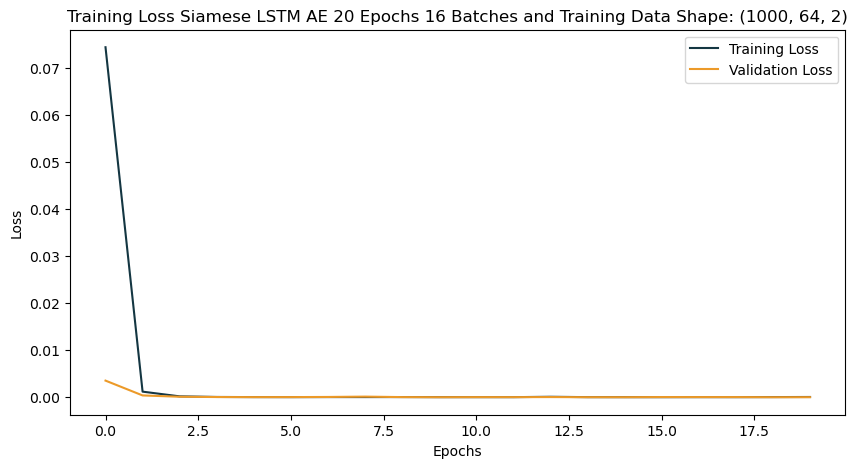

In [14]:
# plots the history
#history = np.load(''../checkpoints/siamese/history/siamese_history.npy')

def plot_history(history, epochs, batch_size, train_data_noisy):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training Loss Siamese LSTM AE {epochs} Epochs {batch_size} Batches and Training Data Shape: {train_data_noisy.shape}')
    plt.show()

plot_history(history, epochs, batch_size, lines_a_noisy)

## Post-Training

In [19]:
# Load model and weights 
#siamese_autoencoder = tf.keras.models.load_model(f'../checkpoints/siamese/model/{batch_size}_batches_{epochs}_epochs_rw_newLoss_newModel_{timestamp}.keras', custom_objects={'siamese_loss': loss})
siamese_autoencoder.load_weights(filepath=f'../checkpoints/siamese/weights/{batch_size}_batches_{epochs}_epochs_{timestamp}.weights.h5')

In [20]:
# Prediction 
pred_siamese_a, pred_siamese_b = predict_reconstructed_sequences(siamese_autoencoder, lines_a_noisy_test, lines_b_noisy_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step


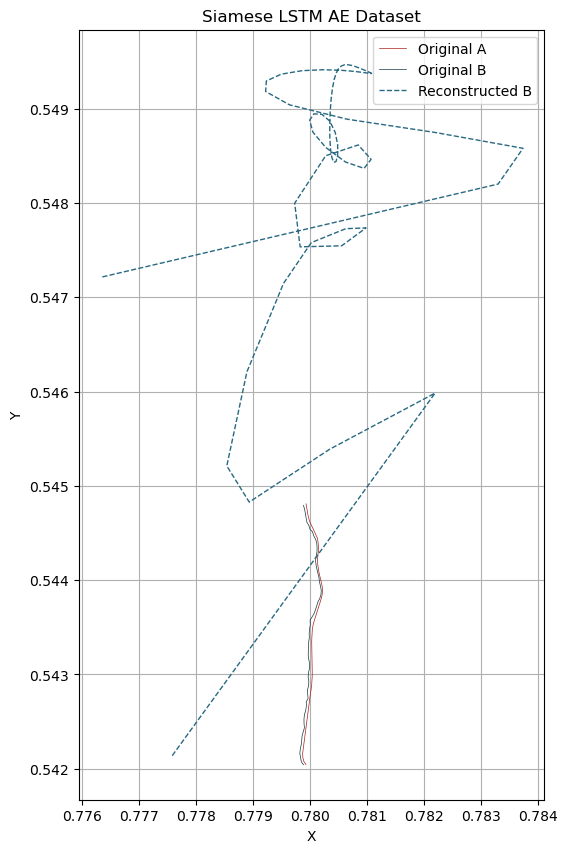

In [24]:
# Plot Results 
plt.figure(figsize=(6, 10))
start_plot = 10
end_plot = start_plot + 1

# lines_a_noisy_test, lines_b_noisy_test, lines_a_clean_test, lines_b_clean_test 

# Plot training segments A
for i, segment in enumerate(lines_a_noisy_test[start_plot:end_plot,:,:]):
    plt.plot(segment[:, 0], segment[:, 1],
             color='#A8201A', linewidth=0.5,
             label='Original A' if i == 0 else "")
      # plt.plot(segment[0:1, 0], segment[0:1, 1],
      #     color='#009FE3', marker='o', markersize=1,
      #     label='Input A' if i == 0 else "")

# Plot training segments B
for i, segment in enumerate(lines_b_noisy_test[start_plot:end_plot,:,:]):
    plt.plot(segment[:, 0], segment[:, 1],
             color='#143642', linewidth=0.5,
             label='Original B' if i == 0 else "")
    # plt.plot(segment[0:1, 0], segment[0:1, 1],
    #       color='#FFC000', marker='o', markersize=1,
    #       label='Input B' if i == 0 else "")


# Plot predicted segments A
# for i, segment in enumerate(pred_siamese_a[start_plot:end_plot,:,:]):
#      plt.plot(segment[:, 0], segment[:, 1],
#             color='#EC9A29', linestyle='--', linewidth=1,
#             label='Reconstructed A' if i == 0 else "")
#     # plt.plot(segment[0:1, 0], segment[0:1, 1],
#     #       color='#00305D', marker='o', markersize=1,
#     #       label='Prediction A' if i == 0 else "")

# Plot predicted segments B
for i, segment in enumerate(pred_siamese_b[start_plot:end_plot,:,:]):
     plt.plot(segment[:, 0], segment[:, 1],
            color="#286981", linestyle='--', linewidth=1,
            label='Reconstructed B' if i == 0 else "")
    # plt.plot(segment[0:1, 0], segment[0:1, 1],
    #          color='#65B32E', marker='o', markersize=1,
    #          label='Prediction B' if i == 0 else "")

plt.title('Siamese LSTM AE Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
mse_b = mean_squared_error(lines_b_clean_test.reshape(-1, 2), pred_siamese_b.reshape(-1, 2))
print(f"Mean Squared Error (MSE): {mse_b}")

Mean Squared Error (MSE): 9.632899639536056e-06


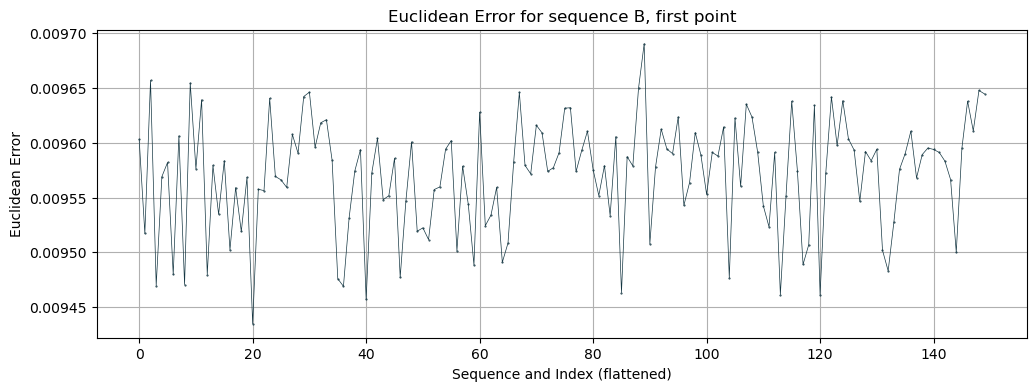

In [33]:
# Compute Euclidean error for all sequences and timesteps

#all_errors_a = np.linalg.norm(lines_a_clean_test[:] - pred_siamese_a[:], axis=-1)
all_errors_b = np.linalg.norm(lines_b_clean_test[:,0,:] - pred_siamese_b[:,0,:], axis=-1)

# Flatten all errors into one 1D array
#all_errors_flat_a = all_errors_a.flatten()  # shape: [num_sequences * sequence_length]
all_errors_flat_b = all_errors_b.flatten()

# Plot all errors as one continuous line
plt.figure(figsize=(12, 4))
#plt.plot(all_errors_flat_a, color='#003f5c', linewidth=0.1, marker='o', linestyle='-', label='Errors A')
plt.plot(all_errors_flat_b, color='#143642', linewidth=0.5, marker='o', linestyle='-', markersize=0.5, label='Errors B')
plt.title('Euclidean Error for sequence B, first point')
plt.xlabel('Sequence and Index (flattened)')
plt.ylabel('Euclidean Error')
plt.grid(True)
plt.show()

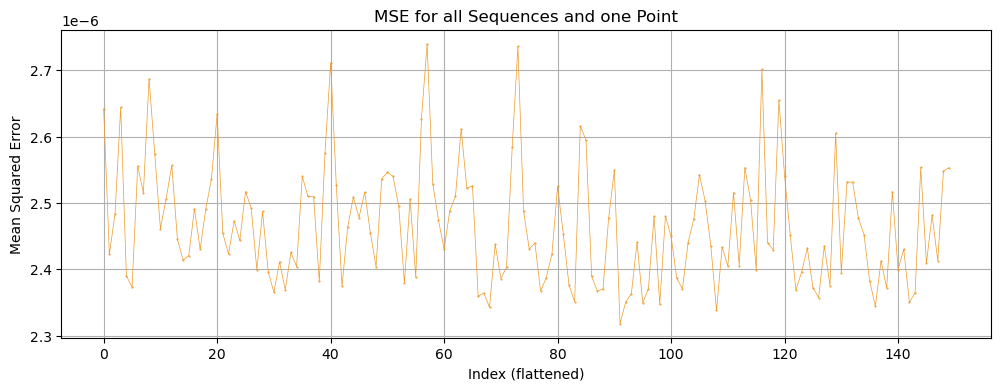

In [25]:
# Compute MSE per point (squared error averaged over features)
mse_all = np.mean((lines_b_clean_test[:,0,:] - pred_siamese_b[:,0,:]) ** 2, axis=-1)  # shape: [num_sequences, sequence_length]

# Flatten for one continuous plot
mse_all_flat = mse_all.flatten()

plt.figure(figsize=(12, 4))
plt.plot(mse_all_flat, color='#EC9A29', linewidth=0.5, marker='o', markersize=0.5,linestyle='-')
plt.title('MSE for all Sequences and one Point')
plt.xlabel('Index (flattened)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()